<a href="https://colab.research.google.com/github/enriquefroes/treinadores-brasileirao-2026/blob/main/notebooks/02_isolando_o_treinador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/analise_treinadores_brasileirao'
except ImportError:
    BASE = './analise_treinadores_brasileirao'

DADOS, GRAF, TAB = (os.path.join(BASE, p) for p in ['dados', 'graficos', 'tabelas'])
for p in (GRAF, TAB):
    os.makedirs(p, exist_ok=True)
if not os.path.exists(os.path.join(DADOS, 'jogos_por_treinador.csv')):
    raise FileNotFoundError('Rode primeiro o notebook 00_dados.ipynb')
jogos = pd.read_csv(os.path.join(DADOS, 'jogos_por_treinador.csv'), parse_dates=['data'])
folha = pd.read_csv(os.path.join(DADOS, 'folha.csv'))

K = 10
MIN_JOGOS = 5
JOGOS_TEMPORADA = 38

MEDIA_PPJ = jogos['pontos'].mean()

def resumo(df, chaves=('clube', 'treinador')):
    g = df.groupby(list(chaves))
    r = g.agg(jogos=('pontos', 'size'), pontos=('pontos', 'sum'),
              vitorias=('pontos', lambda s: (s == 3).sum()), empates=('pontos', lambda s: (s == 1).sum()),
              derrotas=('pontos', lambda s: (s == 0).sum()), gols_pro=('gols_pro', 'sum'), gols_contra=('gols_contra', 'sum'),
              primeiro_jogo=('data', 'min'), ultimo_jogo=('data', 'max'), tipo=('tipo', 'first')).reset_index()
    r['ppj'] = r['pontos'] / r['jogos']
    r['aproveitamento'] = r['ppj'] / 3 * 100
    r['primeiro_jogo'] = r['primeiro_jogo'].dt.date
    r['ultimo_jogo'] = r['ultimo_jogo'].dt.date
    return r

def rotulo(r):
    return f"{r['treinador']} ({r['clube']})" + (' · interino' if r['tipo'] == 'interino' else '')

def salvar(nome):
    plt.tight_layout()
    plt.savefig(os.path.join(GRAF, nome), dpi=150, bbox_inches='tight')
    plt.show()
    print('Salvo em', os.path.join(GRAF, nome))

Mounted at /content/drive


In [2]:
j = jogos.copy()
soma = j.groupby(['adversario', 'mando'])['pontos'].agg(['sum', 'count'])
chave = list(zip(j['adversario'], j['mando']))
j['esperado'] = [(soma.loc[k, 'sum'] - p) / (soma.loc[k, 'count'] - 1) for k, p in zip(chave, j['pontos'])]
j['acima_esperado'] = j['pontos'] - j['esperado']
print(f'Pontos esperados médios: casa {j[j.mando=="casa"].esperado.mean():.2f} · fora {j[j.mando=="fora"].esperado.mean():.2f}')

Pontos esperados médios: casa 1.69 · fora 1.04


Correlação log(folha) x pontos por jogo: 0.68


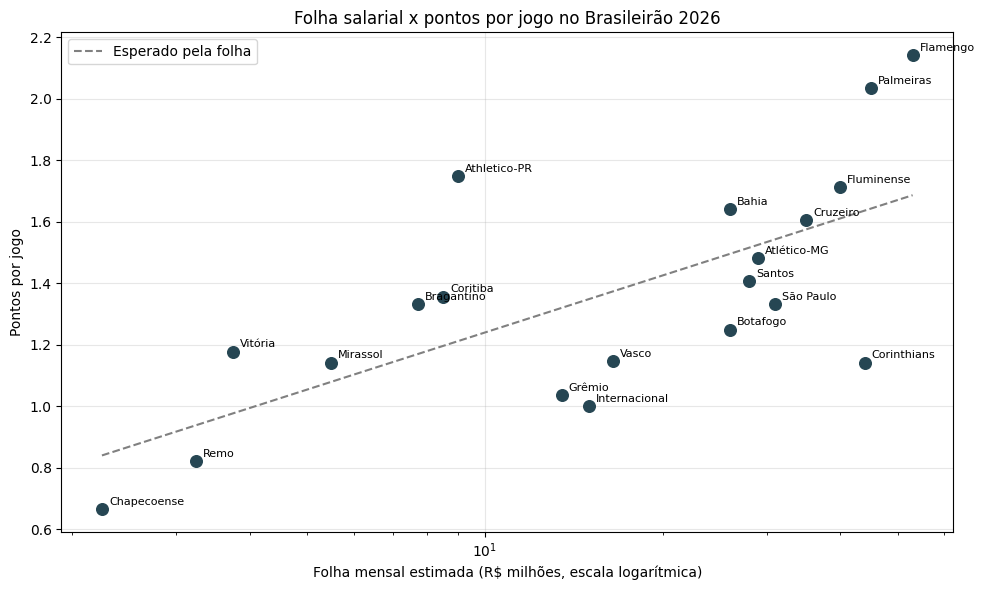

Salvo em /content/drive/MyDrive/analise_treinadores_brasileirao/graficos/02a_folha_x_desempenho.png


In [3]:
clube = j.groupby('clube')['pontos'].mean().rename('ppj_clube').reset_index().merge(folha, on='clube')
coef = np.polyfit(np.log(clube['folha_mensal']), clube['ppj_clube'], 1)
folha['ppj_esperado_folha'] = np.polyval(coef, np.log(folha['folha_mensal']))
print(f"Correlação log(folha) x pontos por jogo: {np.corrcoef(np.log(clube['folha_mensal']), clube['ppj_clube'])[0,1]:.2f}")
j = j.merge(folha[['clube', 'ppj_esperado_folha']], on='clube')

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(clube['folha_mensal'], clube['ppj_clube'], s=70, color='#264653', zorder=3)
xs = np.linspace(clube['folha_mensal'].min(), clube['folha_mensal'].max(), 100)
ax.plot(xs, np.polyval(coef, np.log(xs)), '--', color='gray', label='Esperado pela folha')
for _, c in clube.iterrows():
    ax.annotate(c['clube'], (c['folha_mensal'], c['ppj_clube']), xytext=(5, 3), textcoords='offset points', fontsize=8)
ax.set_xscale('log')
ax.set_xlabel('Folha mensal estimada (R$ milhões, escala logarítmica)')
ax.set_ylabel('Pontos por jogo')
ax.set_title('Folha salarial x pontos por jogo no Brasileirão 2026', fontsize=12)
ax.legend(); ax.grid(alpha=0.3)
salvar('02a_folha_x_desempenho.png')

In [4]:
r = resumo(j)
extra = j.groupby(['clube', 'treinador']).agg(soma_acima=('acima_esperado', 'sum'), esperado_folha=('ppj_esperado_folha', 'first')).reset_index()
r = r.merge(extra, on=['clube', 'treinador'])

r['ppj_ajustado'] = (r['pontos'] + K * MEDIA_PPJ) / (r['jogos'] + K)
r['aproveitamento_ajustado'] = r['ppj_ajustado'] / 3 * 100
r['acima_adversarios_por_jogo'] = r['soma_acima'] / (r['jogos'] + K)                                  # 0 = neutro
r['acima_folha_por_jogo'] = (r['ppj'] - r['esperado_folha']) * r['jogos'] / (r['jogos'] + K)         # 0 = neutro
r['pontos_em_38_ajustado'] = (r['ppj_ajustado'] * JOGOS_TEMPORADA).round(0).astype(int)

tabela = r[['treinador', 'clube', 'tipo', 'jogos', 'aproveitamento', 'aproveitamento_ajustado', 'pontos_em_38_ajustado',
            'acima_adversarios_por_jogo', 'acima_folha_por_jogo']].sort_values('acima_adversarios_por_jogo', ascending=False).round(2)
tabela.to_csv(os.path.join(TAB, '02_treinadores_ajustado.csv'), index=False)
tabela

,treinador,clube,tipo,jogos,aproveitamento,aproveitamento_ajustado,pontos_em_38_ajustado,acima_adversarios_por_jogo,acima_folha_por_jogo
20,Leonardo Jardim,Flamengo,efetivo,25,74.67,66.30,76,0.64,0.40
27,Abel Ferreira,Palmeiras,efetivo,28,67.86,61.94,71,0.48,0.29
16,Artur Jorge,Cruzeiro,efetivo,20,68.33,60.68,69,0.41,0.32
22,Marcão,Fluminense,efetivo,6,72.22,55.44,63,0.36,0.21
34,Hernán Crespo,São Paulo,efetivo,4,83.33,56.21,64,0.32,0.27
0,Odair Hellmann,Athletico-PR,efetivo,28,58.33,54.92,63,0.30,0.40
4,Rogério Ceni,Bahia,efetivo,28,54.76,52.29,60,0.18,0.11
1,Eduardo Domínguez,Atlético-MG,efetivo,23,55.07,52.13,59,0.15,0.09
31,Cuca,Santos,efetivo,20,53.33,50.68,58,0.12,0.06
21,Luis Zubeldía,Fluminense,efetivo,22,53.03,50.64,58,0.11,-0.01


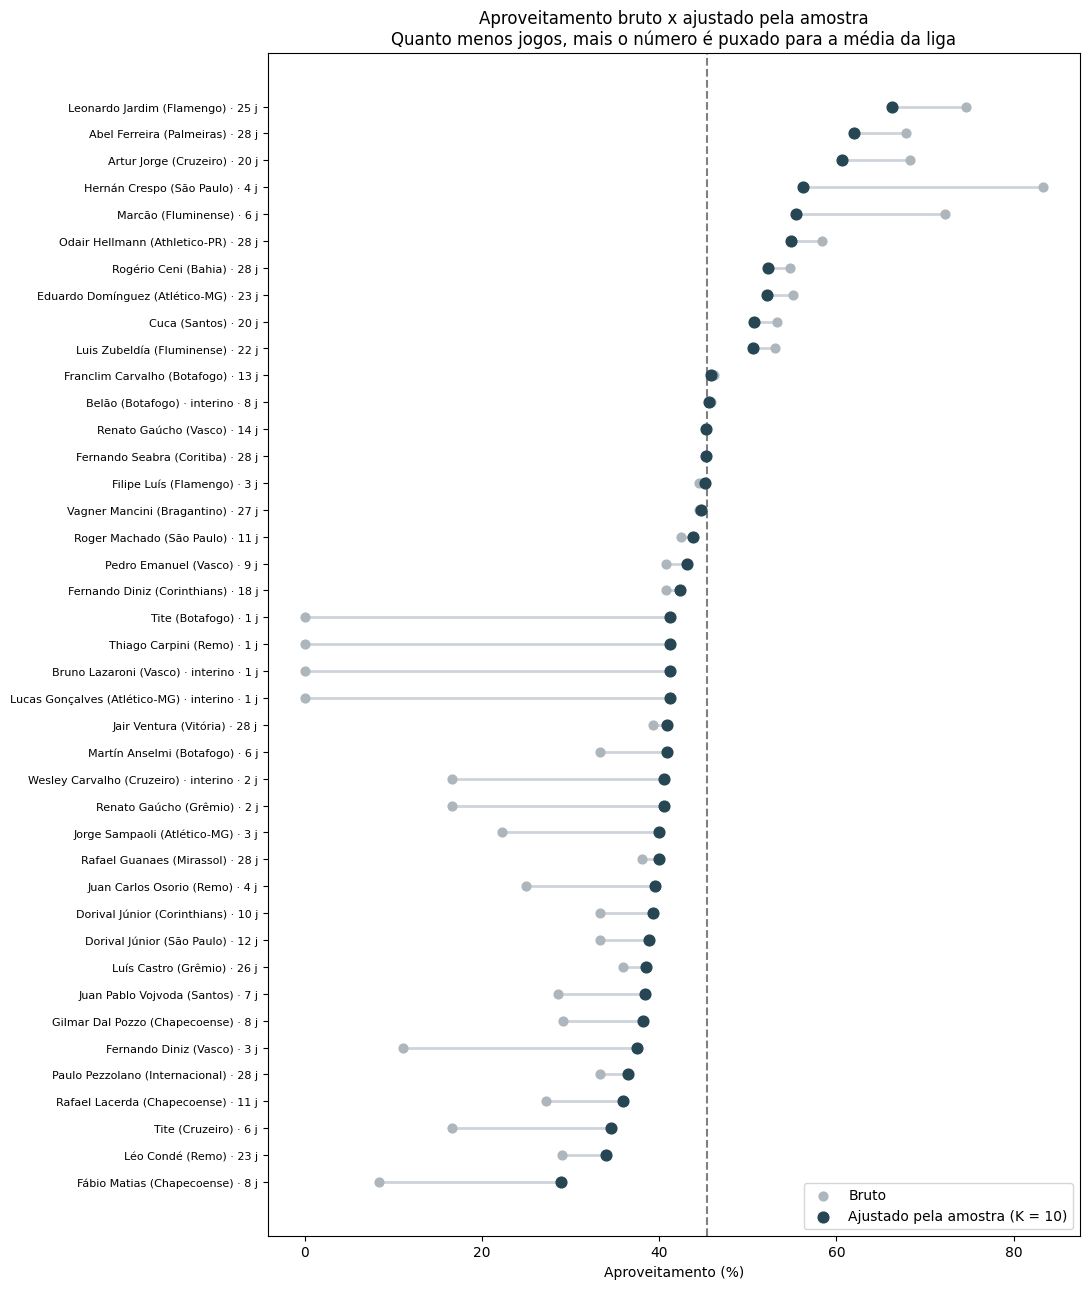

Salvo em /content/drive/MyDrive/analise_treinadores_brasileirao/graficos/02b_bruto_x_ajustado.png


In [5]:
t = r.sort_values('aproveitamento_ajustado')
fig, ax = plt.subplots(figsize=(11, 13))
y = np.arange(len(t))
ax.hlines(y, t['aproveitamento'], t['aproveitamento_ajustado'], color='#ced4da', lw=2)
ax.scatter(t['aproveitamento'], y, color='#adb5bd', s=40, label='Bruto', zorder=3)
ax.scatter(t['aproveitamento_ajustado'], y, color='#264653', s=60, label=f'Ajustado pela amostra (K = {K})', zorder=3)
ax.set_yticks(y)
ax.set_yticklabels([f"{rotulo(x)} · {x['jogos']} j" for _, x in t.iterrows()], fontsize=8)
ax.axvline(MEDIA_PPJ / 3 * 100, ls='--', color='gray')
ax.set_xlabel('Aproveitamento (%)')
ax.set_title('Aproveitamento bruto x ajustado pela amostra\nQuanto menos jogos, mais o número é puxado para a média da liga', fontsize=12)
ax.legend(loc='lower right')
salvar('02b_bruto_x_ajustado.png')

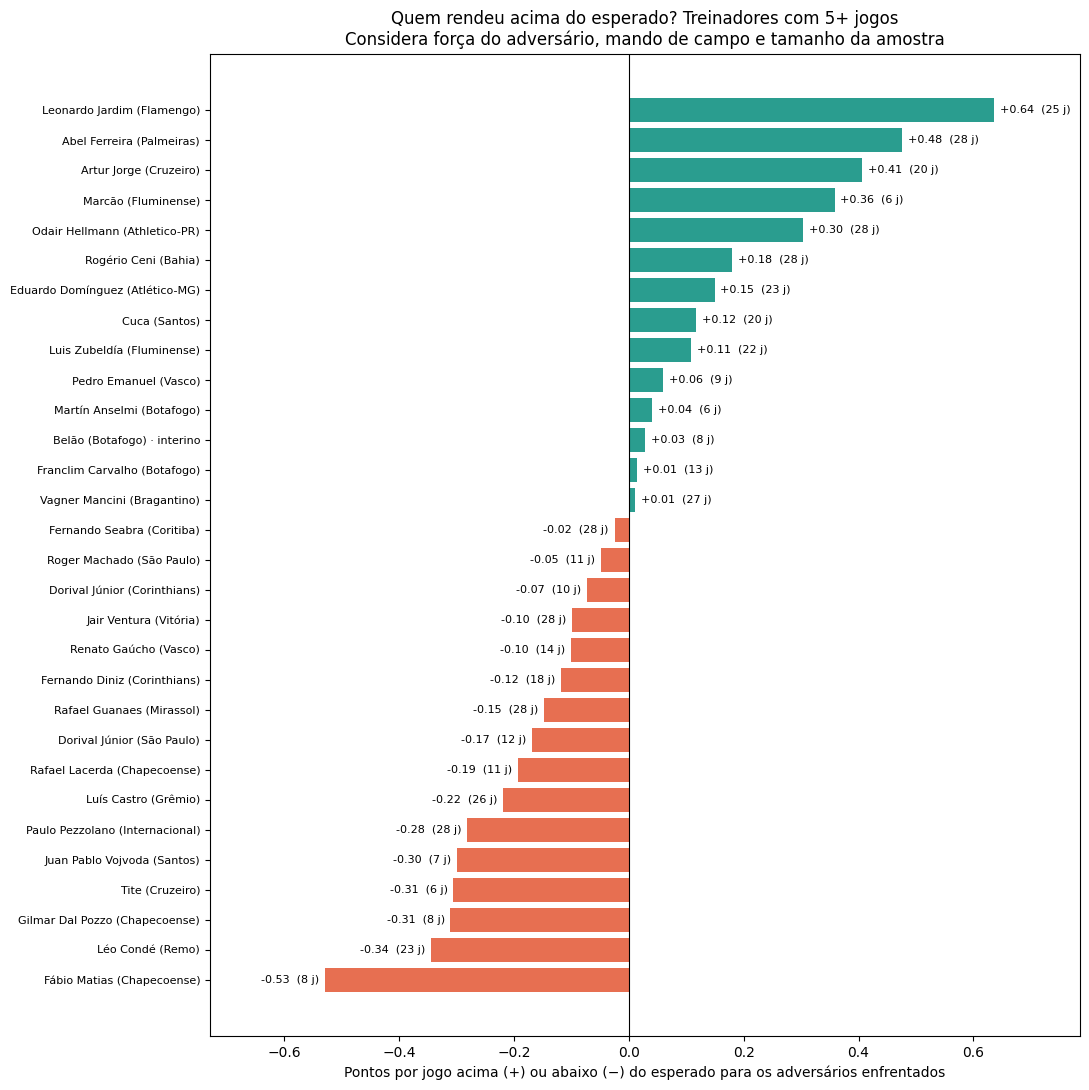

Salvo em /content/drive/MyDrive/analise_treinadores_brasileirao/graficos/02c_ranking_acima_esperado.png


In [6]:
t = r[r['jogos'] >= MIN_JOGOS].sort_values('acima_adversarios_por_jogo')
fig, ax = plt.subplots(figsize=(11, 11))
cores = ['#2a9d8f' if v > 0 else '#e76f51' for v in t['acima_adversarios_por_jogo']]
ax.barh([rotulo(x) for _, x in t.iterrows()], t['acima_adversarios_por_jogo'], color=cores)
for i, (v, jg, f) in enumerate(zip(t['acima_adversarios_por_jogo'], t['jogos'], t['acima_folha_por_jogo'])):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f'{v:+.2f}  ({jg} j)', va='center', ha='left' if v >= 0 else 'right', fontsize=8)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlim(t['acima_adversarios_por_jogo'].min() - 0.2, t['acima_adversarios_por_jogo'].max() + 0.15)
ax.set_xlabel('Pontos por jogo acima (+) ou abaixo (−) do esperado para os adversários enfrentados')
ax.set_title(f'Quem rendeu acima do esperado? Treinadores com {MIN_JOGOS}+ jogos\n'
             'Considera força do adversário, mando de campo e tamanho da amostra', fontsize=12)
ax.tick_params(axis='y', labelsize=8)
salvar('02c_ranking_acima_esperado.png')

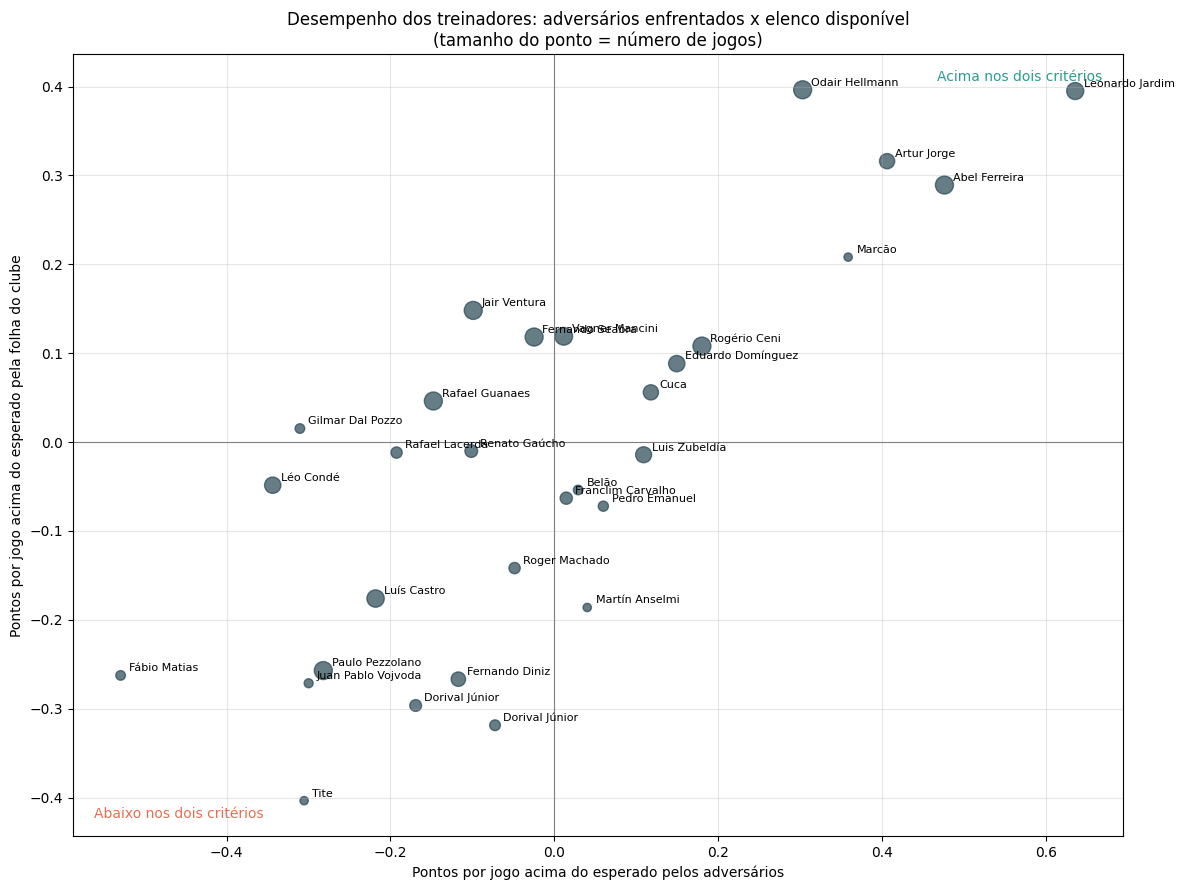

Salvo em /content/drive/MyDrive/analise_treinadores_brasileirao/graficos/02d_adversarios_x_folha.png


In [7]:
t = r[r['jogos'] >= MIN_JOGOS]
fig, ax = plt.subplots(figsize=(12, 9))
ax.scatter(t['acima_adversarios_por_jogo'], t['acima_folha_por_jogo'], s=t['jogos'] * 6, color='#264653', alpha=0.7)
for _, x in t.iterrows():
    ax.annotate(x['treinador'], (x['acima_adversarios_por_jogo'], x['acima_folha_por_jogo']), xytext=(6, 3), textcoords='offset points', fontsize=8)
ax.axhline(0, color='gray', lw=0.8); ax.axvline(0, color='gray', lw=0.8)
ax.text(0.98, 0.98, 'Acima nos dois critérios', transform=ax.transAxes, ha='right', va='top', color='#2a9d8f', fontsize=10)
ax.text(0.02, 0.02, 'Abaixo nos dois critérios', transform=ax.transAxes, ha='left', va='bottom', color='#e76f51', fontsize=10)
ax.set_xlabel('Pontos por jogo acima do esperado pelos adversários')
ax.set_ylabel('Pontos por jogo acima do esperado pela folha do clube')
ax.set_title('Desempenho dos treinadores: adversários enfrentados x elenco disponível\n(tamanho do ponto = número de jogos)', fontsize=12)
ax.grid(alpha=0.3)
salvar('02d_adversarios_x_folha.png')

In [8]:
h = r.sort_values('pontos_em_38_ajustado', ascending=False).reset_index(drop=True)
h.index = h.index + 1
print('TABELA HIPOTÉTICA AJUSTADA (38 jogos, aproveitamento ajustado pela amostra)')
print(h[['treinador', 'clube', 'jogos', 'aproveitamento', 'aproveitamento_ajustado', 'pontos_em_38_ajustado']].round(1).to_string())
h[['treinador', 'clube', 'jogos', 'aproveitamento', 'aproveitamento_ajustado', 'pontos_em_38_ajustado']].to_csv(os.path.join(TAB, '02_tabela_hipotetica_ajustada.csv'))

TABELA HIPOTÉTICA AJUSTADA (38 jogos, aproveitamento ajustado pela amostra)
             treinador          clube  jogos  aproveitamento  aproveitamento_ajustado  pontos_em_38_ajustado
1      Leonardo Jardim       Flamengo     25            74.7                     66.3                     76
2        Abel Ferreira      Palmeiras     28            67.9                     61.9                     71
3          Artur Jorge       Cruzeiro     20            68.3                     60.7                     69
4        Hernán Crespo      São Paulo      4            83.3                     56.2                     64
5               Marcão     Fluminense      6            72.2                     55.4                     63
6       Odair Hellmann   Athletico-PR     28            58.3                     54.9                     63
7         Rogério Ceni          Bahia     28            54.8                     52.3                     60
8    Eduardo Domínguez    Atlético-MG     23        